# Customer Support Ticket Analytics System
## Text Analytics & NLP



---
## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import bigrams
from collections import Counter

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

# Download required NLTK data
for pkg in ['stopwords', 'punkt', 'punkt_tab', 'wordnet']:
    nltk.download(pkg, quiet=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
print('All imports OK')

All imports OK


---
## 2. Load Data

In [2]:
df = pd.read_csv('C:/Users/Tarun/OneDrive/Desktop/Project 3/Data Sets/Clean_Dataset.csv')

print(f'Shape: {df.shape}')
print(f'\nCategories ({df["category"].nunique()}):')  
print(df['category'].value_counts())

df[['issue_description', 'resolution_notes', 'category']].head(5)

Shape: (200000, 35)

Categories (10):
category
Feature Request              20169
Subscription Cancellation    20096
Performance Issue            20074
Security Concern             20040
Login Issue                  20002
Payment Problem              19997
Bug Report                   19981
Refund Request               19900
Data Sync Issue              19877
Account Suspension           19864
Name: count, dtype: int64


,issue_description,resolution_notes,category
0,The payment was deducted from my bank account but the transaction shows failed.,Data synchronization restored after backend service restart.,Account Suspension
1,I found a bug in the latest update affecting report generation.,Provided step-by-step troubleshooting instructions and issue resolved.,Performance Issue
2,The application crashes whenever I try to upload a file.,Provided step-by-step troubleshooting instructions and issue resolved.,Performance Issue
3,My subscription was cancelled without my request and I need clarification.,Provided step-by-step troubleshooting instructions and issue resolved.,Subscription Cancellation
4,The system is not syncing data across devices properly.,We have reset the account credentials and advised the customer to retry login.,Feature Request


---
## 3. Text Preprocessing Pipeline

Steps applied to each text field:
1. Lowercase
2. Remove punctuation & numbers
3. Tokenise
4. Remove stopwords
5. Lemmatise

In [3]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Clean, tokenise, remove stopwords, lemmatise."""
    if pd.isna(text):
        return ''
    # Lowercase & strip non-alpha
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenise
    tokens = word_tokenize(text)
    # Remove stopwords + short tokens
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    # Lemmatise
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Apply to both text columns
print('Preprocessing issue_description...')
df['issue_clean'] = df['issue_description'].apply(preprocess_text)

print('Preprocessing resolution_notes...')
df['resolution_clean'] = df['resolution_notes'].apply(preprocess_text)

print('Done.')

# Preview
pd.DataFrame({
    'Original': df['issue_description'].head(4),
    'Cleaned':  df['issue_clean'].head(4)
})

Preprocessing issue_description...
Preprocessing resolution_notes...
Done.


,Original,Cleaned
0,The payment was deducted from my bank account but the transaction shows failed.,payment deducted bank account transaction show failed
1,I found a bug in the latest update affecting report generation.,found bug latest update affecting report generation
2,The application crashes whenever I try to upload a file.,application crash whenever try upload file
3,My subscription was cancelled without my request and I need clarification.,subscription cancelled without request need clarification


---
## 4. Word Frequency Analysis — Top Keywords per Category

In [4]:
def top_keywords(df, category_col, text_col, top_n=10):
    """Return top N keywords for each category."""
    results = {}
    for cat in sorted(df[category_col].unique()):
        words = ' '.join(df[df[category_col] == cat][text_col]).split()
        freq = Counter(words).most_common(top_n)
        results[cat] = freq
    return results

kw = top_keywords(df, 'category', 'issue_clean', top_n=8)

# Display as a readable table
rows = []
for cat, words in kw.items():
    rows.append({'Category': cat, 'Top Keywords': ', '.join([f"{w}({c})" for w, c in words])})

pd.DataFrame(rows)

,Category,Top Keywords
0,Account Suspension,"account(3991), request(3909), seems(2051), discrepancy(2051), billing(2051),..."
1,Bug Report,"request(3993), account(3971), experiencing(2057), slow(2057), performance(20..."
2,Data Sync Issue,"account(4030), request(3981), would(2037), like(2037), refund(2037), recent(..."
3,Feature Request,"request(4098), account(4002), would(2083), like(2083), refund(2083), recent(..."
4,Login Issue,"request(3984), account(3926), seems(2093), discrepancy(2093), billing(2093),..."
5,Payment Problem,"account(4079), request(3997), unable(2056), access(2056), entering(2056), co..."
6,Performance Issue,"request(4057), account(3992), system(2055), syncing(2055), data(2055), acros..."
7,Refund Request,"account(4024), request(3929), found(2070), bug(2070), latest(2070), update(2..."
8,Security Concern,"account(4145), request(3920), payment(2083), deducted(2083), bank(2083), tra..."
9,Subscription Cancellation,"account(4023), request(4022), seems(2133), discrepancy(2133), billing(2133),..."


---
## 5. Recurring Issue Detection — Top Bigrams per Category

Bigrams (two-word phrases) reveal *recurring pain points* more specifically than single keywords.

In [5]:
def top_bigrams(df, category_col, text_col, top_n=5):
    """Return top N bigrams per category."""
    results = {}
    for cat in sorted(df[category_col].unique()):
        tokens = ' '.join(df[df[category_col] == cat][text_col]).split()
        bg = list(bigrams(tokens))
        freq = Counter(bg).most_common(top_n)
        results[cat] = [(' '.join(pair), count) for pair, count in freq]
    return results

bg = top_bigrams(df, 'category', 'issue_clean', top_n=5)

rows = []
for cat, phrases in bg.items():
    rows.append({'Category': cat, 'Recurring Phrases': ', '.join([f"{p}({c})" for p, c in phrases])})

pd.DataFrame(rows)

,Category,Recurring Phrases
0,Account Suspension,"seems discrepancy(2051), discrepancy billing(2051), billing statement(2051),..."
1,Bug Report,"experiencing slow(2057), slow performance(2057), performance using(2057), us..."
2,Data Sync Issue,"would like(2037), like request(2037), request refund(2037), refund recent(20..."
3,Feature Request,"would like(2083), like request(2083), request refund(2083), refund recent(20..."
4,Login Issue,"seems discrepancy(2093), discrepancy billing(2093), billing statement(2093),..."
5,Payment Problem,"unable access(2056), access account(2056), account entering(2056), entering ..."
6,Performance Issue,"system syncing(2055), syncing data(2055), data across(2055), across device(2..."
7,Refund Request,"found bug(2070), bug latest(2070), latest update(2070), update affecting(207..."
8,Security Concern,"payment deducted(2083), deducted bank(2083), bank account(2083), account tra..."
9,Subscription Cancellation,"seems discrepancy(2133), discrepancy billing(2133), billing statement(2133),..."


---
## 6. TF-IDF Vectorisation + Ticket Classification

**Goal:** Train a model that reads `issue_description` and predicts `category`.  
This mirrors the *Ticket Classification* module of the project.

**Model choice:** Logistic Regression with TF-IDF — fast, interpretable, strong baseline for short support texts.

In [6]:
X = df['issue_clean']
y = df['category']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {len(X_train):,}')
print(f'Test size  : {len(X_test):,}')

Train size : 160,000
Test size  : 40,000


In [7]:
# Build pipeline: TF-IDF → Logistic Regression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,    # top 5k terms
        ngram_range=(1, 2),   # unigrams + bigrams
        min_df=5,             # ignore very rare terms
        sublinear_tf=True     # log(1 + tf) scaling
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=5,                  # slight regularisation
        solver='lbfgs',
        multi_class='multinomial',
        random_state=42
    ))
])

print('Training classifier...')
pipeline.fit(X_train, y_train)
print('Done.')

Training classifier...
Done.


---
## 7. Model Evaluation

In [8]:
y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc:.4f} ({acc*100:.2f}%)')

Test Accuracy: 0.1008 (10.08%)


In [9]:
print('=== Classification Report ===')
print(classification_report(y_test, y_pred))

=== Classification Report ===
                           precision    recall  f1-score   support

       Account Suspension       0.09      0.09      0.09      3973
               Bug Report       0.10      0.10      0.10      3996
          Data Sync Issue       0.00      0.00      0.00      3976
          Feature Request       0.11      0.10      0.11      4034
              Login Issue       0.10      0.11      0.11      4000
          Payment Problem       0.00      0.00      0.00      3999
        Performance Issue       0.09      0.09      0.09      4015
           Refund Request       0.09      0.09      0.09      3980
         Security Concern       0.10      0.20      0.13      4008
Subscription Cancellation       0.10      0.21      0.14      4019

                 accuracy                           0.10     40000
                macro avg       0.08      0.10      0.09     40000
             weighted avg       0.08      0.10      0.09     40000



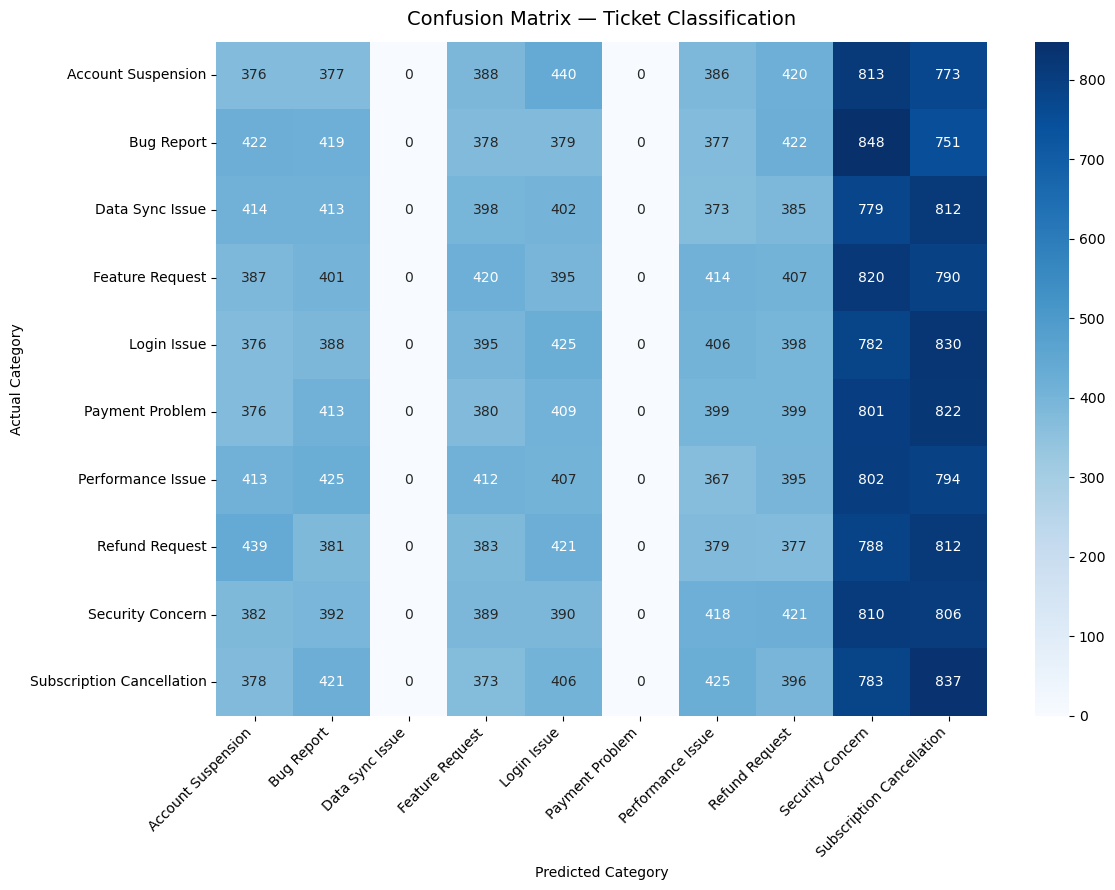

In [11]:
# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels, ax=ax
)
ax.set_title('Confusion Matrix — Ticket Classification', fontsize=14, pad=12)
ax.set_xlabel('Predicted Category')
ax.set_ylabel('Actual Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [12]:
# Top TF-IDF features per category
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coef = pipeline.named_steps['clf'].coef_
class_labels = pipeline.named_steps['clf'].classes_

print('=== Top 8 Discriminating Terms per Category ===')
for i, cat in enumerate(class_labels):
    top_idx = np.argsort(coef[i])[-8:][::-1]
    top_terms = [feature_names[j] for j in top_idx]
    print(f'{cat:30s}: {top_terms}')

=== Top 8 Discriminating Terms per Category ===
Account Suspension            : ['using dashboard', 'using', 'slow', 'slow performance', 'performance', 'dashboard', 'experiencing slow', 'experiencing']
Bug Report                    : ['syncing', 'syncing data', 'system', 'system syncing', 'across device', 'across', 'device', 'data across']
Data Sync Issue               : ['would like', 'would', 'refund recent', 'refund', 'recent charge', 'request refund', 'charge', 'like request']
Feature Request               : ['seems discrepancy', 'seems', 'statement month', 'statement', 'discrepancy billing', 'billing', 'billing statement', 'discrepancy']
Login Issue                   : ['twofactor authentication', 'twofactor', 'code delivered', 'code', 'authentication', 'authentication code', 'delivered', 'delivered phone']
Payment Problem               : ['syncing', 'syncing data', 'system', 'system syncing', 'across device', 'across', 'device', 'data across']
Performance Issue             : ['re

---
## 8. Apply Classifier to Full Dataset

Add model-predicted category and confidence score as new columns.

In [13]:
df['predicted_category']    = pipeline.predict(df['issue_clean'])
df['prediction_confidence'] = pipeline.predict_proba(df['issue_clean']).max(axis=1).round(4)

# Match rate — how often does model agree with existing label?
match = (df['predicted_category'] == df['category']).mean()
print(f'Label agreement (model vs existing): {match:.2%}')

df[['issue_description', 'category', 'predicted_category', 'prediction_confidence']].head(8)

Label agreement (model vs existing): 10.31%


,issue_description,category,predicted_category,prediction_confidence
0,The payment was deducted from my bank account but the transaction shows failed.,Account Suspension,Security Concern,0.1040
1,I found a bug in the latest update affecting report generation.,Performance Issue,Refund Request,0.1067
2,The application crashes whenever I try to upload a file.,Performance Issue,Security Concern,0.1022
3,My subscription was cancelled without my request and I need clarification.,Subscription Cancellation,Performance Issue,0.1028
4,The system is not syncing data across devices properly.,Feature Request,Bug Report,0.1028
5,There seems to be a discrepancy in my billing statement for this month.,Payment Problem,Subscription Cancellation,0.1047
6,I would like to request a refund for the recent charge.,Security Concern,Feature Request,0.1035
7,Two-factor authentication codes are not being delivered to my phone.,Subscription Cancellation,Login Issue,0.1044


---
## 9. Sentiment Proxy Scoring on Resolution Notes

We don't have customer sentiment labels, but we can build a **proxy score** using a keyword lexicon approach:  
- Positive signals (resolved, fixed, helped, working, success…) → higher score  
- Negative signals (escalated, failed, unresolved, pending, waiting…) → lower score  

This gives each ticket a resolution sentiment score from **-1 (bad)** to **+1 (good)**.

In [14]:
POSITIVE_KEYWORDS = {
    'resolved', 'fixed', 'restored', 'helped', 'working', 'success',
    'completed', 'confirmed', 'successful', 'reset', 'provided',
    'troubleshoot', 'advised', 'updated', 'corrected', 'approved'
}

NEGATIVE_KEYWORDS = {
    'escalated', 'failed', 'unresolved', 'pending', 'waiting',
    'error', 'issue', 'problem', 'unable', 'cannot', 'not', 'delay',
    'breach', 'complaint', 'rejected', 'blocked', 'suspended'
}

def resolution_sentiment(text):
    """Return a score in [-1, 1] based on keyword presence."""
    if not text:
        return 0.0
    tokens = set(text.split())
    pos = len(tokens & POSITIVE_KEYWORDS)
    neg = len(tokens & NEGATIVE_KEYWORDS)
    total = pos + neg
    if total == 0:
        return 0.0
    return round((pos - neg) / total, 4)

df['resolution_sentiment_score'] = df['resolution_clean'].apply(resolution_sentiment)

print('Sentiment Score Distribution:')
print(df['resolution_sentiment_score'].describe().round(3))
print('\nMean score by category:')
print(df.groupby('category')['resolution_sentiment_score'].mean().sort_values(ascending=False).round(3))

Sentiment Score Distribution:
count    200000.000
mean          0.402
std           0.512
min          -0.333
25%           0.000
50%           0.333
75%           1.000
max           1.000
Name: resolution_sentiment_score, dtype: float64

Mean score by category:
category
Account Suspension           0.406
Security Concern             0.405
Refund Request               0.403
Data Sync Issue              0.403
Login Issue                  0.401
Subscription Cancellation    0.401
Feature Request              0.401
Payment Problem              0.400
Bug Report                   0.399
Performance Issue            0.399
Name: resolution_sentiment_score, dtype: float64


---
## 10. Export Enriched Dataset

In [15]:
# Columns added in this phase
nlp_cols = [
    'issue_clean',
    'resolution_clean',
    'predicted_category',
    'prediction_confidence',
    'resolution_sentiment_score'
]

print('New columns added this phase:')
for c in nlp_cols:
    print(f'  {c}')

output_path = 'C:/Users/Tarun/OneDrive/Desktop/Project 3/Data Sets/NLP_enriched_tickets.csv'
df.to_csv(output_path, index=False)
print(f'\nExported → {output_path}')
print(f'Final shape: {df.shape}')

New columns added this phase:
  issue_clean
  resolution_clean
  predicted_category
  prediction_confidence
  resolution_sentiment_score

Exported → C:/Users/Tarun/OneDrive/Desktop/Project 3/Data Sets/NLP_enriched_tickets.csv
Final shape: (200000, 40)
